In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torchvision.datasets as datasets
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [24]:
def get_data():

    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

    data = pd.read_csv(url, sep=";")
    data.head()

    # choose 10 random values in the "resiudal sugar" and replace them with NaN
    idx = np.random.choice(data.index, size=10, replace=False)
    y_test = data.loc[idx, "residual sugar"]
    data.loc[idx, "residual sugar"] = np.nan

    # split the data into train (has residual sugar) and test (missing values)
    train_data = data.dropna(subset="residual sugar")
    test_data = data[data["residual sugar"].isna()]

    X_train = train_data.drop("residual sugar", axis=1)
    y_train = train_data["residual sugar"]
    X_test = test_data.drop("residual sugar", axis=1)

    # scale the data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # transform to tensors
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_test = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

    return X_train, y_train, X_test, y_test

In [25]:
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size*2)
        self.fc3 = nn.Linear(hidden_size*2, hidden_size)
        self.fc4 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x
    
def train_one_epoch(model, train_dl, optimizer, loss_fn):
    model.train()
    epoch_loss = []

    for X_batch, y_batch in train_dl:
        output = model(X_batch)
        loss = loss_fn(output, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss.append(loss.item())
        
    return np.mean(epoch_loss)

def train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs):
    
    train_loss = np.zeros(epochs)
    test_loss = np.zeros(epochs)
    
    for epoch in range(epochs):
        train_loss[epoch] = train_one_epoch(model, train_dl, optimizer, loss_fn)
        
        model.eval()
        with torch.no_grad():
            for X_batch, y_batch in test_dl:
                output = model(X_batch)
                test_loss[epoch] = loss_fn(output, y_batch).item() 

    return train_loss, test_loss

In [26]:
learning_rate = 0.001
epochs = 500

loss_fn = nn.MSELoss()
model = SimpleNN(input_size=11, hidden_size=16, output_size=1)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

X_train, y_train, X_test, y_test = get_data()
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_dl = DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=True)
test_dl = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0], shuffle=False)

train_loss, test_loss = train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs)

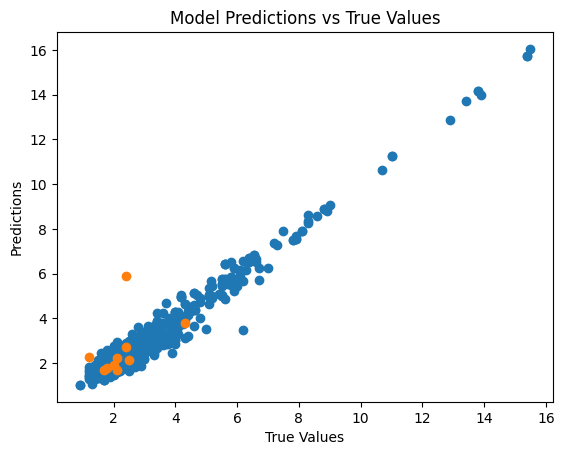

In [ ]:
# plot model predictions vs true values

output_test = model(X_test)
output_train = model(X_train)
# Use .detach() to remove the graph tracking, then convert to numpy
plt.scatter(y_train.detach().cpu().numpy(), output_train.detach().cpu().numpy())
plt.scatter(y_test.detach().cpu().numpy(), output_test.detach().cpu().numpy())
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('Model Predictions vs True Values')
plt.show()

# the models handles pretty well not just the train values but also the test ones (the missing ones), except
# for one bad prediction, which is acceptable.